# Train MobileNet

This notebook trains the MobileNet model for recycling classification.

In [1]:
import sys
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from pathlib import Path

# Add project root to path
project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.utils.config import Config
from src.data.dataset import RecyclingDataset
from src.data.augmentation import get_train_transforms, get_val_transforms
from src.models.mobilenet import MobileNetClassifier, export_to_onnx, export_to_torchscript
from src.training.trainer import Trainer
from src.training.losses import get_loss_function
from src.training.callbacks import ModelCheckpoint, EarlyStopping
from src.utils.visualization import plot_training_history, show_batch

/Users/naopersonal/Documents/GitHub/TP-final-vision/venv/lib/python3.13/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)>
  data = fetch_version_info()
/Users/naopersonal/Documents/GitHub/TP-final-vision/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Setup

In [2]:
# Load config
config = Config('../configs/mobilenet_config.yaml')

# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Create directories
Path('../outputs/checkpoints').mkdir(parents=True, exist_ok=True)
Path('../outputs/logs').mkdir(parents=True, exist_ok=True)
Path('../outputs/exports').mkdir(parents=True, exist_ok=True)

Using device: cpu


## 2. Data Loading

In [3]:
# Transforms
img_size = config.data.get('image_size', 224)
train_transforms = get_train_transforms(img_size)
val_transforms = get_val_transforms(img_size)

# Datasets
processed_dir = Path('../') / config.data.get('processed_dir')
train_dataset = RecyclingDataset(processed_dir / 'train.csv', root_dir='../data', transforms=train_transforms)
val_dataset = RecyclingDataset(processed_dir / 'val.csv', root_dir='../data', transforms=val_transforms)

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Classes: {train_dataset.class2idx}")

# Dataloaders
batch_size = config.training.get('batch_size', 32)
num_workers = config.training.get('num_workers', 2)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

Train size: 68
Val size: 15
Classes: {'ecoglasses': 0}


/Users/naopersonal/Documents/GitHub/TP-final-vision/src/data/augmentation.py:25: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),


## 3. Visualize Batch

/Users/naopersonal/Documents/GitHub/TP-final-vision/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/naopersonal/Documents/GitHub/TP-final-vision/venv/lib/python3.13/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)>
  data = fetch_version_info()
/Users/naopersonal/Documents/GitHub/TP-final-vision/venv/lib/python3.13/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)>
  data = fetch_version_info()
/Users/naopersonal/Documents/GitHub/TP-final-vision/venv/lib/python3.13/site-packages/albu

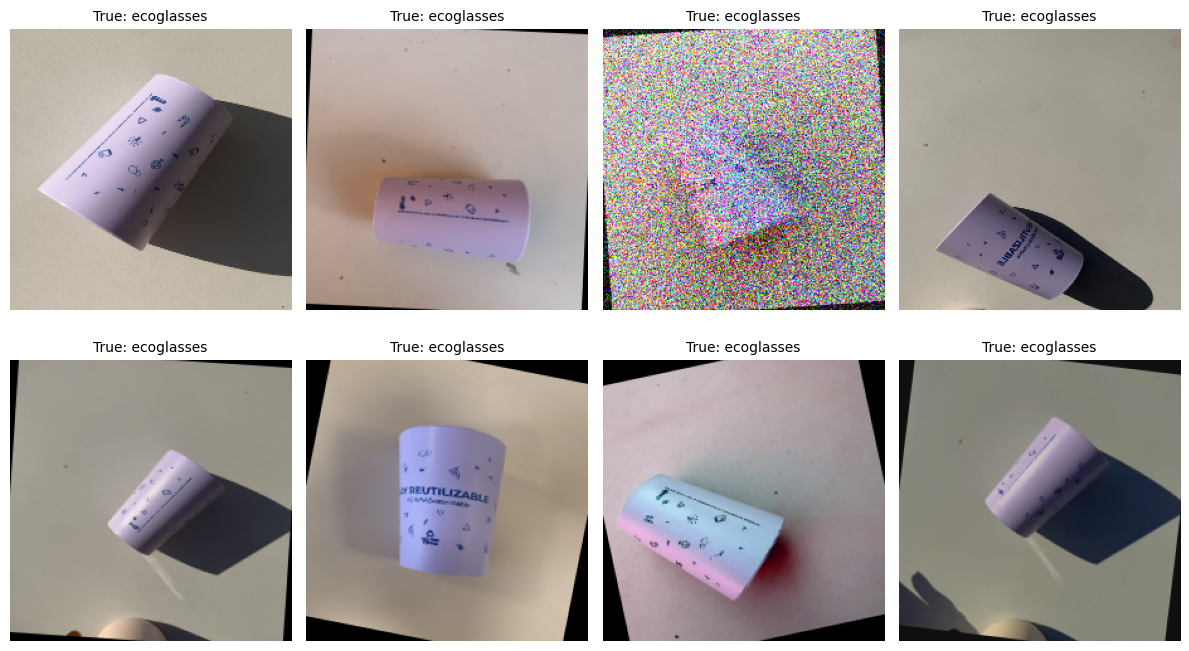

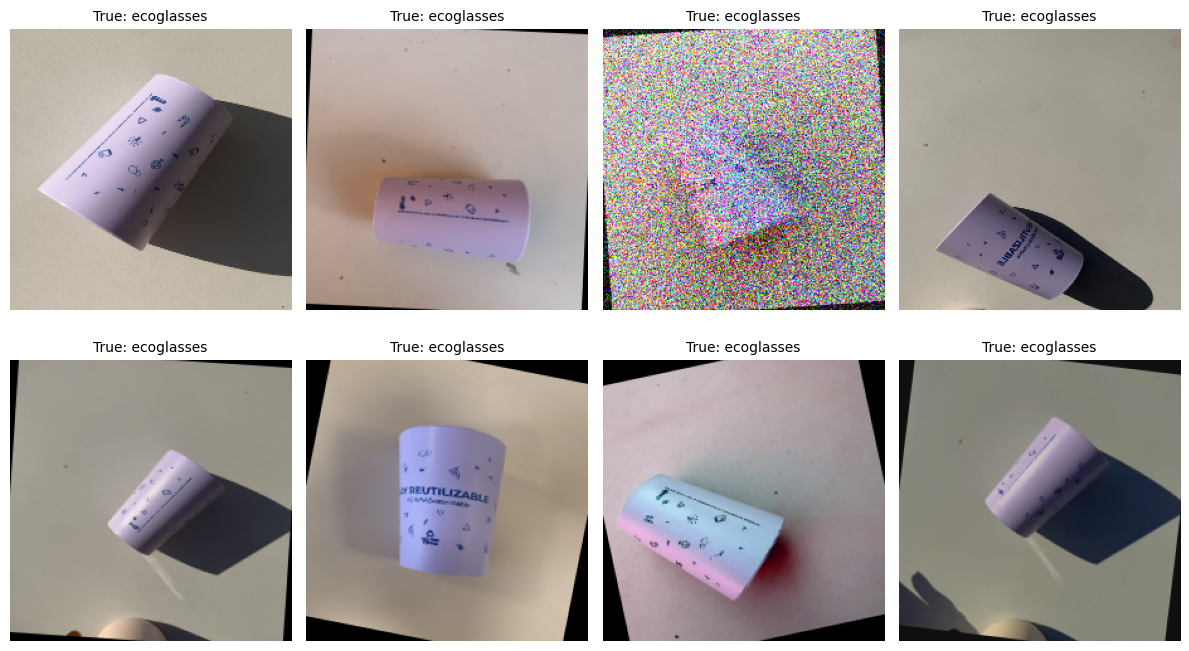

In [4]:
# Show sample batch
images, labels = next(iter(train_loader))
show_batch(images, labels, train_dataset.idx2class)

## 4. Model Initialization

In [5]:
import ssl
import certifi

ssl_context = ssl.create_default_context(cafile=certifi.where())
ssl._create_default_https_context = lambda *args, **kwargs: ssl_context

model = MobileNetClassifier(
    num_classes=config.model.get('num_classes'),
    architecture=config.model.get('architecture'),
    pretrained=config.model.get('pretrained'),
    dropout=config.model.get('dropout')
)
print(f"Model created: {config.model.get('architecture')}")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /Users/naopersonal/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 49.5MB/s]


Model created: mobilenet_v3_large


## 5. Training Setup

In [ ]:
# Loss and Optimizer
criterion = get_loss_function(config.training, device)
optimizer = optim.Adam(
    model.parameters(), 
    lr=float(config.training.get('learning_rate')), 
    weight_decay=float(config.training.get('weight_decay'))
)

# Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=config.training.get('epochs')
)

# Callbacks
callbacks = [
    ModelCheckpoint(dirpath='../outputs/checkpoints', monitor='val_f1_macro', mode='max'),
    EarlyStopping(monitor='val_loss', patience=config.training.get('early_stopping', {}).get('patience', 5))
]

# Trainer
trainer = Trainer(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    config=config._config,
    scheduler=scheduler,
    callbacks=callbacks
)

TypeError: float() argument must be a string or a real number, not 'NoneType'

## 6. Train

In [ ]:
epochs = config.training.get('epochs', 10)
history = trainer.fit(train_loader, val_loader, epochs=epochs)

## 7. Results

In [ ]:
plot_training_history(history)

## 8. Export Model

In [ ]:
# Load best model
best_model_path = '../outputs/checkpoints/best_model.pt'
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])

# Export
export_to_onnx(model, '../outputs/exports/mobilenet.onnx')
export_to_torchscript(model, '../outputs/exports/mobilenet_ts.pt')